
### Creating and Fixing Mode Collapse in a GAN

### Objective :

The objective of this assignment is to practically understand mode collapse, one of the
common problems faced while training GANs.

In [1]:
# STEP 1: CHECK GPU

import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [2]:
# STEP 2: IMPORT LIBRARIES

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# STEP 3: SET COMMON PARAMETERS

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BATCH_SIZE = 128
LATENT_DIM = 100
EPOCHS = 20

IMAGE_SIZE = 28
NUM_CHANNELS = 1

print("Device:", DEVICE)
print("Batch Size:", BATCH_SIZE)
print("Latent Dimension:", LATENT_DIM)
print("Epochs:", EPOCHS)

Device: cuda
Batch Size: 128
Latent Dimension: 100
Epochs: 20


In [4]:
# STEP 4: LOAD FASHION-MNIST DATASET

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Dataset loaded successfully!")
print("Number of training images:", len(train_dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.5MB/s]

Dataset loaded successfully!
Number of training images: 60000


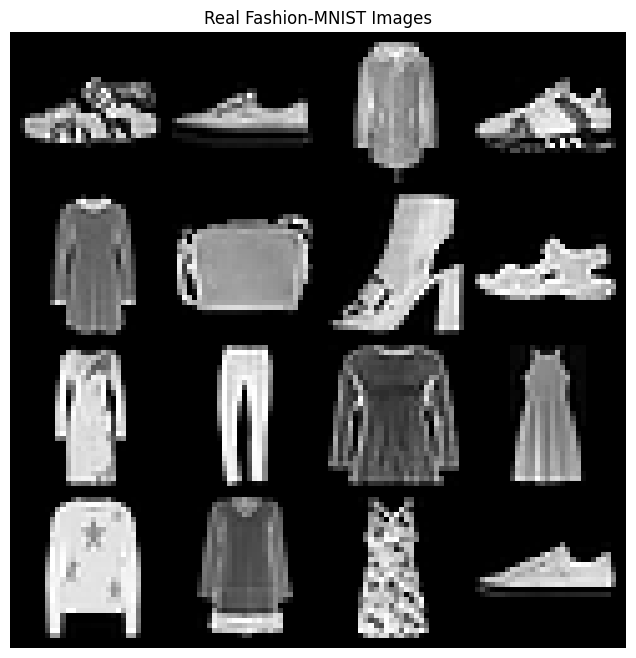

In [5]:
# STEP 5: DISPLAY REAL FASHION-MNIST IMAGES

images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 8))

grid = make_grid(
    images[:16],
    nrow=4,
    normalize=True,
    padding=2
)

plt.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray"
)

plt.title("Real Fashion-MNIST Images")
plt.axis("off")
plt.show()

In [6]:
# STEP 6: DEFINE GENERATOR

class Generator(nn.Module):

    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # 100 -> 128 x 7 x 7
            nn.ConvTranspose2d(
                latent_dim,
                128,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 7 x 7 -> 14 x 14
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 14 x 14 -> 28 x 28
            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


print("Generator defined successfully!")

Generator defined successfully!


In [7]:
# STEP 7: DEFINE DISCRIMINATOR

class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # 28 x 28 -> 14 x 14
            nn.Conv2d(
                1,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 14 x 14 -> 7 x 7
            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 7 x 7 -> 1
            nn.Conv2d(
                128,
                1,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            )
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)


print("Discriminator defined successfully!")

Discriminator defined successfully!


In [8]:
# STEP 8: INITIALIZE GAN WEIGHTS

def initialize_weights(model):

    for module in model.modules():

        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(
                module.weight.data,
                0.0,
                0.02
            )

        elif isinstance(module, nn.BatchNorm2d):
            nn.init.normal_(
                module.weight.data,
                1.0,
                0.02
            )
            nn.init.constant_(
                module.bias.data,
                0
            )


print("Weight initialization function created.")

Weight initialization function created.


In [9]:
# STEP 9: CREATE FIXED NOISE

fixed_noise = torch.randn(
    16,
    LATENT_DIM,
    1,
    1,
    device=DEVICE
)

print("Fixed noise created:", fixed_noise.shape)

Fixed noise created: torch.Size([16, 100, 1, 1])


In [10]:
# STEP 10: CREATE OUTPUT FOLDERS

BROKEN_DIR = "assignment7_broken"
BROKEN_GRID_DIR = os.path.join(BROKEN_DIR, "grids")

IMPROVED_DIR = "assignment7_improved"
IMPROVED_GRID_DIR = os.path.join(IMPROVED_DIR, "grids")

os.makedirs(BROKEN_GRID_DIR, exist_ok=True)
os.makedirs(IMPROVED_GRID_DIR, exist_ok=True)

print("Output folders created.")

Output folders created.


In [11]:

# STEP 11: CREATE INTENTIONALLY UNSTABLE GAN

G_broken = Generator(LATENT_DIM).to(DEVICE)
D_broken = Discriminator().to(DEVICE)

initialize_weights(G_broken)
initialize_weights(D_broken)

print("Generator:")
print(G_broken)

print("\nDiscriminator:")
print(D_broken)

Generator:
Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)

Discriminator:
Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)


In [12]:
# STEP 12: SET BROKEN MODEL LOSS AND OPTIMIZERS

criterion = nn.BCEWithLogitsLoss()

# Intentionally high learning rate
BROKEN_LR = 0.002

optimizer_G_broken = optim.Adam(
    G_broken.parameters(),
    lr=BROKEN_LR,
    betas=(0.5, 0.999)
)

optimizer_D_broken = optim.Adam(
    D_broken.parameters(),
    lr=BROKEN_LR,
    betas=(0.5, 0.999)
)

print("Broken GAN learning rate:", BROKEN_LR)

Broken GAN learning rate: 0.002


In [13]:
# STEP 13: TRAIN INTENTIONALLY UNSTABLE GAN

print("Starting Part A: Intentionally unstable GAN")
print("Learning rate:", BROKEN_LR)
print("Epochs:", EPOCHS)

for epoch in range(1, EPOCHS + 1):

    G_broken.train()
    D_broken.train()

    total_loss_D = 0
    total_loss_G = 0

    for real_images, _ in train_loader:

        real_images = real_images.to(DEVICE)
        batch_size = real_images.size(0)

        # --------------------------------
        # Train Discriminator
        # --------------------------------

        optimizer_D_broken.zero_grad()

        real_labels = torch.ones(
            batch_size,
            1,
            device=DEVICE
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=DEVICE
        )

        # Real images
        real_output = D_broken(real_images)

        loss_real = criterion(
            real_output,
            real_labels
        )

        # Fake images
        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=DEVICE
        )

        fake_images = G_broken(noise)

        fake_output = D_broken(
            fake_images.detach()
        )

        loss_fake = criterion(
            fake_output,
            fake_labels
        )

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D_broken.step()

        # --------------------------------
        # Train Generator
        # --------------------------------

        optimizer_G_broken.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=DEVICE
        )

        generated_images = G_broken(noise)

        output = D_broken(generated_images)

        # Generator wants discriminator to classify
        # fake images as real
        loss_G = criterion(
            output,
            real_labels
        )

        loss_G.backward()
        optimizer_G_broken.step()

        total_loss_D += loss_D.item()
        total_loss_G += loss_G.item()

    avg_loss_D = total_loss_D / len(train_loader)
    avg_loss_G = total_loss_G / len(train_loader)

    # --------------------------------
    # Generate fixed images
    # --------------------------------

    G_broken.eval()

    with torch.no_grad():
        generated = G_broken(fixed_noise)

    image_path = os.path.join(
        BROKEN_GRID_DIR,
        f"generated_epoch_{epoch}.png"
    )

    save_image(
        generated,
        image_path,
        normalize=True,
        nrow=4
    )

    print(
        f"Epoch [{epoch}/{EPOCHS}] "
        f"Loss D: {avg_loss_D:.4f} "
        f"Loss G: {avg_loss_G:.4f}"
    )

print("\nPart A training completed!")

Starting Part A: Intentionally unstable GAN
Learning rate: 0.002
Epochs: 20
Epoch [1/20] Loss D: 1.2205 Loss G: 1.9882
Epoch [2/20] Loss D: 1.2485 Loss G: 1.2447
Epoch [3/20] Loss D: 1.2467 Loss G: 1.1688
Epoch [4/20] Loss D: 1.2520 Loss G: 1.1032
Epoch [5/20] Loss D: 1.2576 Loss G: 1.0979
Epoch [6/20] Loss D: 1.2459 Loss G: 1.1083
Epoch [7/20] Loss D: 1.2472 Loss G: 1.0891
Epoch [8/20] Loss D: 1.2299 Loss G: 1.1057
Epoch [9/20] Loss D: 1.2302 Loss G: 1.1101
Epoch [10/20] Loss D: 1.2228 Loss G: 1.1135
Epoch [11/20] Loss D: 1.2160 Loss G: 1.1248
Epoch [12/20] Loss D: 1.2092 Loss G: 1.1221
Epoch [13/20] Loss D: 1.1997 Loss G: 1.1392
Epoch [14/20] Loss D: 1.1978 Loss G: 1.1434
Epoch [15/20] Loss D: 1.1969 Loss G: 1.1733
Epoch [16/20] Loss D: 1.1628 Loss G: 1.1627
Epoch [17/20] Loss D: 1.1582 Loss G: 1.1879
Epoch [18/20] Loss D: 1.1535 Loss G: 1.2039
Epoch [19/20] Loss D: 1.1475 Loss G: 1.2099
Epoch [20/20] Loss D: 1.1382 Loss G: 1.2389

Part A training completed!


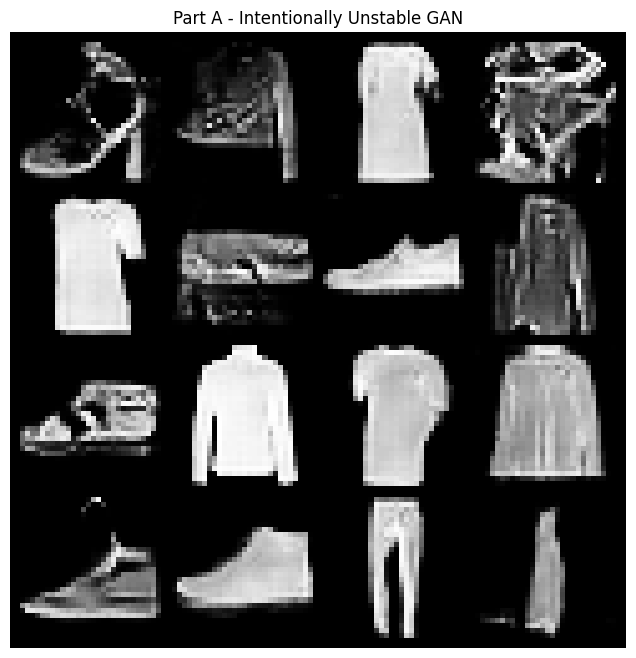

In [14]:

# STEP 14: DISPLAY BROKEN / MODE-COLLAPSE RESULT

broken_image_path = os.path.join(
    BROKEN_GRID_DIR,
    f"generated_epoch_{EPOCHS}.png"
)

broken_images = plt.imread(broken_image_path)

plt.figure(figsize=(8, 8))
plt.imshow(broken_images)
plt.title("Part A - Intentionally Unstable GAN")
plt.axis("off")
plt.show()

In [15]:
# STEP 15: CREATE FRESH GAN FOR IMPROVED EXPERIMENT

G_improved = Generator(LATENT_DIM).to(DEVICE)
D_improved = Discriminator().to(DEVICE)

initialize_weights(G_improved)
initialize_weights(D_improved)

print("Fresh Generator and Discriminator created.")

Fresh Generator and Discriminator created.


In [16]:
# STEP 16: SET IMPROVED MODEL OPTIMIZERS

# Use different learning rates to improve GAN stability
GENERATOR_LR = 0.0002
DISCRIMINATOR_LR = 0.0001

optimizer_G_improved = optim.Adam(
    G_improved.parameters(),
    lr=GENERATOR_LR,
    betas=(0.5, 0.999)
)

optimizer_D_improved = optim.Adam(
    D_improved.parameters(),
    lr=DISCRIMINATOR_LR,
    betas=(0.5, 0.999)
)

print("Generator learning rate:", GENERATOR_LR)
print("Discriminator learning rate:", DISCRIMINATOR_LR)


Generator learning rate: 0.0002
Discriminator learning rate: 0.0001


In [17]:
# STEP 17: TRAIN IMPROVED GAN WITH DIFFERENT LEARNING RATES

print("Starting Part B: Improved GAN")
print("Generator learning rate:", GENERATOR_LR)
print("Discriminator learning rate:", DISCRIMINATOR_LR)
print("Epochs:", EPOCHS)

for epoch in range(1, EPOCHS + 1):

    G_improved.train()
    D_improved.train()

    total_loss_D = 0
    total_loss_G = 0

    for real_images, _ in train_loader:

        real_images = real_images.to(DEVICE)
        batch_size = real_images.size(0)

        # --------------------------------
        # Train Discriminator
        # --------------------------------

        optimizer_D_improved.zero_grad()

        # Standard labels
        real_labels = torch.ones(
            batch_size,
            1,
            device=DEVICE
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=DEVICE
        )

        # Real images
        real_output = D_improved(real_images)

        loss_real = criterion(
            real_output,
            real_labels
        )

        # Fake images
        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=DEVICE
        )

        fake_images = G_improved(noise)

        fake_output = D_improved(
            fake_images.detach()
        )

        loss_fake = criterion(
            fake_output,
            fake_labels
        )

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D_improved.step()

        # --------------------------------
        # Train Generator
        # --------------------------------

        optimizer_G_improved.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=DEVICE
        )

        generated_images = G_improved(noise)

        output = D_improved(generated_images)

        # Generator tries to make fake images
        # classified as real
        loss_G = criterion(
            output,
            real_labels
        )

        loss_G.backward()
        optimizer_G_improved.step()

        total_loss_D += loss_D.item()
        total_loss_G += loss_G.item()

    avg_loss_D = total_loss_D / len(train_loader)
    avg_loss_G = total_loss_G / len(train_loader)

    # --------------------------------
    # Generate fixed images
    # --------------------------------

    G_improved.eval()

    with torch.no_grad():
        generated = G_improved(fixed_noise)

    image_path = os.path.join(
        IMPROVED_GRID_DIR,
        f"generated_epoch_{epoch}.png"
    )

    save_image(
        generated,
        image_path,
        normalize=True,
        nrow=4
    )

    print(
        f"Epoch [{epoch}/{EPOCHS}] "
        f"Loss D: {avg_loss_D:.4f} "
        f"Loss G: {avg_loss_G:.4f}"
    )

print("\nPart B training completed!")


Starting Part B: Improved GAN
Generator learning rate: 0.0002
Discriminator learning rate: 0.0001
Epochs: 20
Epoch [1/20] Loss D: 0.7676 Loss G: 1.3471
Epoch [2/20] Loss D: 0.6944 Loss G: 1.4619
Epoch [3/20] Loss D: 0.9031 Loss G: 1.2177
Epoch [4/20] Loss D: 1.0243 Loss G: 1.0822
Epoch [5/20] Loss D: 1.0790 Loss G: 1.0358
Epoch [6/20] Loss D: 1.1050 Loss G: 1.0203
Epoch [7/20] Loss D: 1.1039 Loss G: 1.0198
Epoch [8/20] Loss D: 1.1095 Loss G: 1.0082
Epoch [9/20] Loss D: 1.1269 Loss G: 1.0044
Epoch [10/20] Loss D: 1.1415 Loss G: 0.9922
Epoch [11/20] Loss D: 1.1484 Loss G: 0.9900
Epoch [12/20] Loss D: 1.1527 Loss G: 0.9841
Epoch [13/20] Loss D: 1.1637 Loss G: 0.9848
Epoch [14/20] Loss D: 1.1526 Loss G: 0.9759
Epoch [15/20] Loss D: 1.1628 Loss G: 0.9799
Epoch [16/20] Loss D: 1.1593 Loss G: 0.9792
Epoch [17/20] Loss D: 1.1640 Loss G: 0.9874
Epoch [18/20] Loss D: 1.1576 Loss G: 0.9808
Epoch [19/20] Loss D: 1.1510 Loss G: 0.9717
Epoch [20/20] Loss D: 1.1578 Loss G: 0.9915

Part B training com

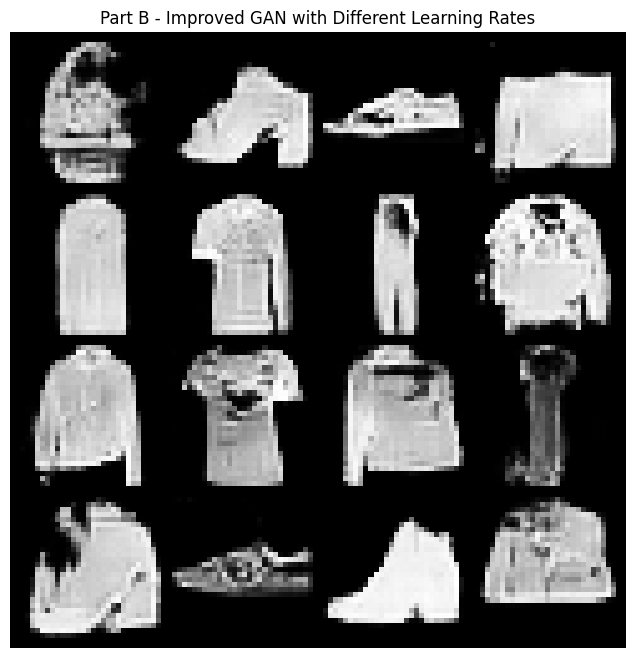

In [18]:
# STEP 18: DISPLAY IMPROVED RESULT

improved_image_path = os.path.join(
    IMPROVED_GRID_DIR,
    f"generated_epoch_{EPOCHS}.png"
)

improved_images = plt.imread(improved_image_path)

plt.figure(figsize=(8, 8))
plt.imshow(improved_images)
plt.title("Part B - Improved GAN with Different Learning Rates")
plt.axis("off")
plt.show()


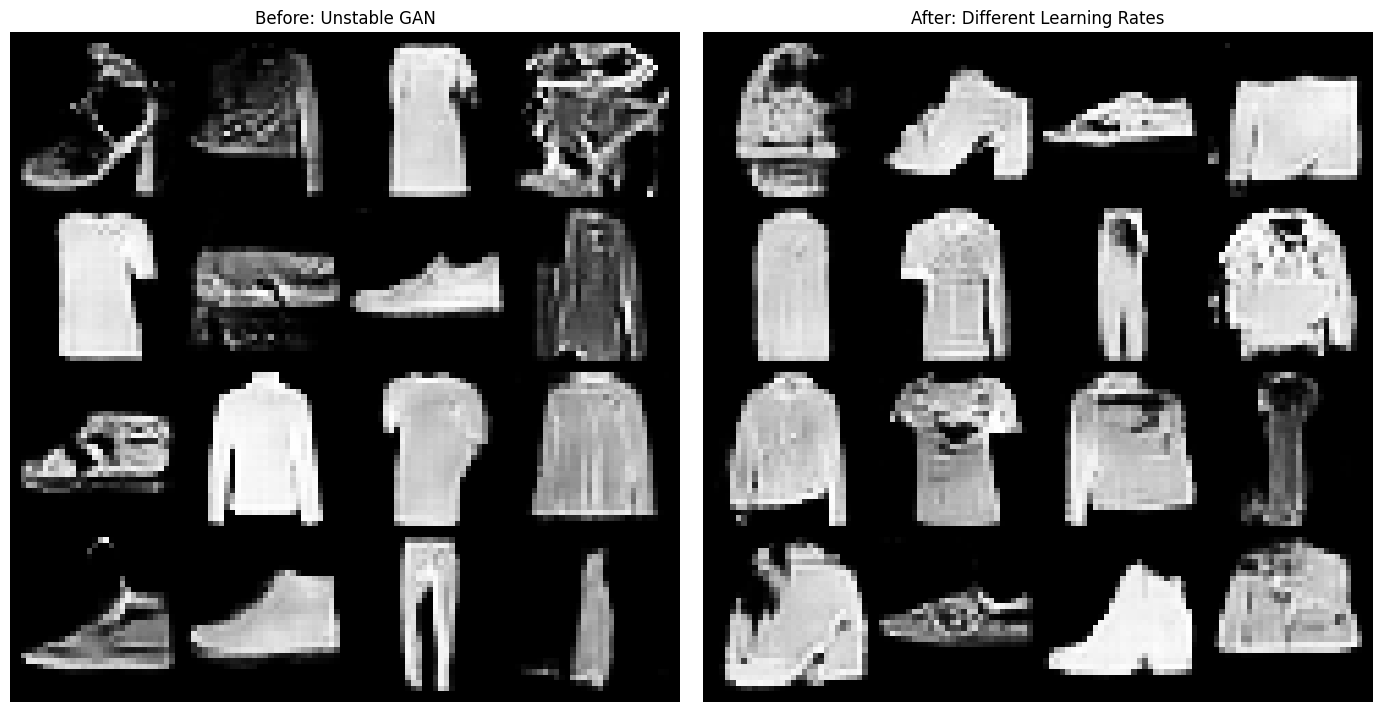

In [19]:
# STEP 19: COMPARE BROKEN AND IMPROVED RESULTS

broken_images = plt.imread(broken_image_path)
improved_images = plt.imread(improved_image_path)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(broken_images)
plt.title("Before: Unstable GAN")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(improved_images)
plt.title("After: Different Learning Rates")
plt.axis("off")

plt.tight_layout()
plt.show()


In [20]:
# STEP 20: SHOW SAVED OUTPUT LOCATIONS

print("Broken experiment:")
print(BROKEN_GRID_DIR)

print("\nImproved experiment:")
print(IMPROVED_GRID_DIR)

print("\nFinal broken image:")
print(broken_image_path)

print("\nFinal improved image:")
print(improved_image_path)

Broken experiment:
assignment7_broken/grids

Improved experiment:
assignment7_improved/grids

Final broken image:
assignment7_broken/grids/generated_epoch_20.png

Final improved image:
assignment7_improved/grids/generated_epoch_20.png


### 1. What modification caused the model to perform poorly?

The model was intentionally made unstable by increasing the learning rate to **0.002**, which is much higher than the typical DCGAN learning rate used in the working model. The high learning rate caused the Generator and Discriminator to update too aggressively, making training unstable.

### 2. What did the generated images look like?

The generated images were **less clear and less diverse**. Some images appeared visually similar to one another, showing reduced diversity and signs of mode collapse.

### 3. Which technique did you use to improve the model?

I used **different learning rates for the Generator and Discriminator**. The Generator used a learning rate of **0.0002**, while the Discriminator used **0.0001**.

### 4. Did the solution improve the output? Why?

Yes. Using different learning rates helped balance the Generator and Discriminator during adversarial training. The Discriminator was updated more slowly, which reduced the chance of one network dominating the training and helped the Generator produce more stable and diverse outputs.

### Conclusion

This experiment demonstrated how an excessively high learning rate can make GAN training unstable and lead to reduced output diversity. Using different learning rates for the Generator and Discriminator helped improve training stability and the quality of the generated Fashion-MNIST images.
